In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
num_samples = 1000

data = pd.DataFrame({
    'customer_id': [f'CUST{i:04d}' for i in range(num_samples)],
    'call_duration': np.random.exponential(scale=100, size=num_samples),
    'data_usage': np.random.gamma(shape=2, scale=2, size=num_samples),
    'contract_length': np.random.randint(1, 24, size=num_samples),
    'churn': np.random.binomial(1, 0.2, size=num_samples)  # 20% churn rate
})


In [4]:
print(data.head())

  customer_id  call_duration  data_usage  contract_length  churn
0    CUST0000      46.926809    3.813529               17      0
1    CUST0001     301.012143    0.937630               13      1
2    CUST0002     131.674569    4.997681               18      1
3    CUST0003      91.294255    6.975058                2      0
4    CUST0004      16.962487    3.155429               13      0


In [5]:
X = data[['call_duration', 'data_usage', 'contract_length']]
y = data['churn']

# 📌 Train-Test Split
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, data['customer_id'], test_size=0.2, random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7591 - loss: 0.6162 - val_accuracy: 0.8000 - val_loss: 0.5830
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7804 - loss: 0.5854 - val_accuracy: 0.8250 - val_loss: 0.5434
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8040 - loss: 0.5553 - val_accuracy: 0.8250 - val_loss: 0.5076
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8109 - loss: 0.5212 - val_accuracy: 0.8250 - val_loss: 0.4823
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7911 - loss: 0.5175 - val_accuracy: 0.8250 - val_loss: 0.4707
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7868 - loss: 0.5261 - val_accuracy: 0.8250 - val_loss: 0.4687
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8168 - loss: 0.4747 - val_accuracy: 0.8250 - val_loss: 0.4672
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7790 - loss: 0.5200 - val_accuracy: 0.8250 - val_loss

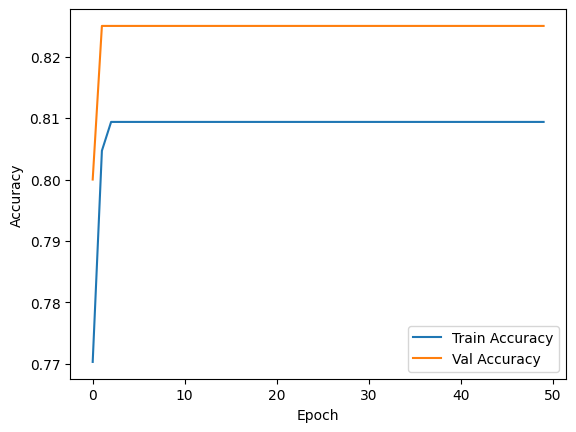

In [7]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 📌 Train the model
history = model.fit(X_train_scaled, y_train, validation_split=0.2,
                    epochs=50, batch_size=32, verbose=1)

# 📌 Plot Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [8]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Test Accuracy: 0.7650
Test F1-Score: 0.0000

Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87       153
           1       0.00      0.00      0.00        47

    accuracy                           0.77       200
   macro avg       0.38      0.50      0.43       200
weighted avg       0.59      0.77      0.66       200



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
at_risk_customers = pd.DataFrame({
    'customer_id': id_test,
    'predicted_churn_probability': y_pred_prob
})
at_risk_customers = at_risk_customers.sort_values(by='predicted_churn_probability', ascending=False)

# Define threshold for at-risk customers (e.g., >0.5)
at_risk = at_risk_customers[at_risk_customers['predicted_churn_probability'] > 0.5]

print(f"\nAt-risk customers (probability > 0.5):\n")
print(at_risk.head())

# 📌 Save at-risk customers to CSV
at_risk.to_csv("at_risk_customers.csv", index=False)
print("\nAt-risk customers saved to at_risk_customers.csv")


At-risk customers (probability > 0.5):

Empty DataFrame
Columns: [customer_id, predicted_churn_probability]
Index: []

At-risk customers saved to at_risk_customers.csv
